# Pyelonephritis urinary peptidomics: BATTLE-AMP scoring

Borgards, Voss et al. (2026) profiled the urinary peptidome of 30 pyelonephritis
(PN) patients by LC-MS/MS native peptidomics, identifying 9,295 endogenous peptide
fragments absent from healthy-control donors. These sequences carry no experimental
antimicrobial activity labels - exactly the setting where BATTLE-AMP adds value.
We apply BATTLE-AMP in scoring mode to rank antimicrobial candidates, prioritising
activity against uropathogenic *E. coli* (UPEC), the dominant pathogen in this cohort.

## 1. Setup

In [10]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.patches import Rectangle
from matplotlib.colors import TwoSlopeNorm
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

PROJECT_ROOT = Path("../..")
FASTA        = PROJECT_ROOT / "datasets" / "pyelonephritis-borgards" / "sequences.fasta"
RESULTS_DIR  = PROJECT_ROOT / "results" / "inference"

plt.rcParams.update({
    "font.size": 7,
    "axes.titlesize": 8,
    "axes.labelsize": 7,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 6,
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "axes.facecolor": "#f0f0f0",
    "figure.facecolor": "white",
})

## 2. Input data

The FASTA file contains 9,295 unique peptides detected by LC–MS/MS in the soluble urine
fraction of PN patients (Borgards et al.) and absent from all healthy-control donors.
Peptide lengths range from 8–25 aa, consistent with endogenous proteolytic fragments.

In [11]:
def read_fasta(path):
    """Read a FASTA file into a list of (header, sequence) tuples."""
    records = []
    header, seq = None, []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line.startswith(">"):
                if header is not None:
                    records.append((header, "".join(seq)))
                header = line[1:]
                seq = []
            else:
                seq.append(line)
        if header is not None:
            records.append((header, "".join(seq)))
    return records


records = read_fasta(FASTA)
seqs = pd.DataFrame(records, columns=["id", "sequence"])
seqs["length"] = seqs["sequence"].str.len()

print(f"Sequences: {len(seqs)}")
print(f"Unique:    {seqs['sequence'].nunique()}")
print(f"Length:    {seqs['length'].min()}-{seqs['length'].max()} aa "
      f"(median {seqs['length'].median():.0f})")

Sequences: 9295
Unique:    9295
Length:    8-25 aa (median 13)


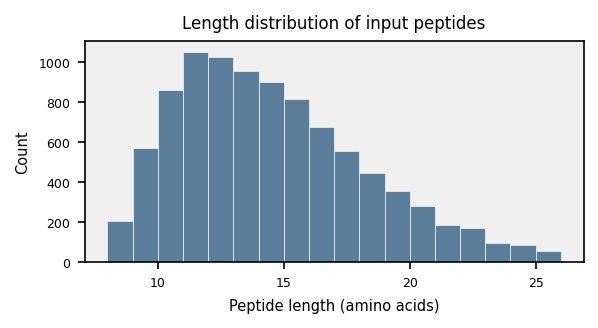

In [12]:
fig, ax = plt.subplots(figsize=(4, 2.2))
ax.hist(seqs["length"], bins=range(seqs["length"].min(), seqs["length"].max() + 2),
        color="#5a7d9a", edgecolor="white", linewidth=0.3)
ax.set_xlabel("Peptide length (amino acids)")
ax.set_ylabel("Count")
ax.set_title("Length distribution of input peptides")
ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
plt.tight_layout()
plt.show()

Length range 8–25 aa falls within the input windows of all models except AMPScanner
(≥10 aa minimum enforced by the pipeline wrapper), so coverage is near-complete.

## 3. Known AMP database check

Before scoring, we check whether any sequences are already catalogued as known AMPs.
`data/amp_positive.fasta` is the aggregated positive set used in BATTLE-AMP, compiled
from dbAMP, AMPScanner, and DRAMP after deduplication (Szymczak et al., Methods).
A hit here means the peptide has prior experimental evidence of antimicrobial activity.
`data/dbaasp/dbaasp_sequences.csv` is used as a proxy for training data overlap:
HydrAMP, MBC-Attention, AMPredictor, and SenseXAMP were all trained on experimental
MIC data, and a sequence present in DBAASP may have been seen during training.

No sequences are excluded from scoring; overlap status is stored for later.

In [24]:
AMP_POS_FASTA = PROJECT_ROOT / "data" / "amp_positive.fasta"
DBAASP_CSV    = PROJECT_ROOT / "data" / "dbaasp" / "dbaasp_sequences.csv"

dramp_seqs  = {seq.upper() for _, seq in read_fasta(AMP_POS_FASTA)}
dbaasp_seqs = set(
    pd.read_csv(DBAASP_CSV, usecols=["sequence"])["sequence"]
    .str.upper().dropna()
)

in_dramp  = seqs["sequence"].str.upper().isin(dramp_seqs)
in_dbaasp = seqs["sequence"].str.upper().isin(dbaasp_seqs)
in_any    = in_dramp | in_dbaasp

seqs["in_dramp"]  = in_dramp.values
seqs["in_dbaasp"] = in_dbaasp.values

print(f"DRAMP (amp_positive.fasta):  {len(dramp_seqs):,} sequences")
print(f"DBAASP:                      {len(dbaasp_seqs):,} sequences")
print(f"Input peptides in DRAMP:     {in_dramp.sum()} / {len(seqs)}")
print(f"Input peptides in DBAASP:    {in_dbaasp.sum()} / {len(seqs)}")
print(f"Input peptides in either:    {in_any.sum()} / {len(seqs)}")
if in_any.any():
    print()
    cols = ["id", "sequence", "in_dramp", "in_dbaasp"]
    print(seqs[in_any][cols].to_string())

DRAMP (amp_positive.fasta):  20,313 sequences
DBAASP:                      13,731 sequences
Input peptides in DRAMP:     11 / 9295
Input peptides in DBAASP:    13 / 9295
Input peptides in either:    21 / 9295

            id                   sequence  in_dramp  in_dbaasp
117    seq_118           ADSGEGDFLAEGGGVR      True       True
1460  seq_1461            DSGEGDFLAEGGGVR     False       True
2305  seq_2306                 FKDLGEENFK     False       True
2842  seq_2843          GLEEELQFSLGSKINVK     False       True
4266  seq_4267     LEKGLDGAKKAVGGLGKLGKDA      True      False
5637  seq_5638                   PPPPPPPP     False       True
5638  seq_5639                  PPPPPPPPP     False       True
5639  seq_5640                 PPPPPPPPPP     False       True
5640  seq_5641                PPPPPPPPPPP     False       True
5641  seq_5642               PPPPPPPPPPPP     False       True
6404  seq_6405          SEETKENEGFTVTAEGK     False       True
7126  seq_7127                SSLL

## 4. Running the pipeline

With `pyelonephritis-borgards` registered in `config/config.yaml`, run:

```bash
snakemake --profile profile/ score \
    --config score_datasets="[pyelonephritis-borgards]"
```

The pipeline pre-filters the FASTA per model according to declared length limits in
each model's `model.yaml`, then runs inference. No evaluation is performed (no
ground-truth labels). Runtime on a single RTX 2080 Ti is ~30–45 min; SenseXAMP
dominates due to serial ESM embedding.

## 5. Loading predictions

Classifiers produce `Prediction` (AMP/non-AMP) and `Probability_score`; regressors
produce `MIC` and `MIC_unit` (µM). Regressor outputs are clamped to [0.25, 512] µM
to suppress out-of-distribution extremes (e.g. DeepAMP_LSTM_G− returns ~14,000 µM
on this dataset).

In [20]:
# Model metadata: variant name -> (display name, type)
CLASSIFIERS = {
    "ampeppy": "amPEPpy",
    "amplify": "AMPlify",
    "ampscanner": "AMPScanner",
    "ampredmfa": "AMPpred-MFA",
    "hydramp-amp-classifier": "HydrAMP_AMP",
    "hydramp-mic-classifier": "HydrAMP_Ec",
    "sensexamp-classifier": "SenseXAMP_clf",
}

REGRESSORS = {
    "sensexamp-ecoli": "SenseXAMP_Ec",
    "sensexamp-saureus": "SenseXAMP_Sa",
    "apex-ecoli": "APEX_Ec",
    "apex-min": "APEX_min",
    "mbc-attention": "MBC-Attention",
    "ampredictor": "AMPredictor",
    "deep-amp-cnn-gramneg": "DeepAMP_CNN,G-",
    "deep-amp-lstm-gramneg": "DeepAMP_LSTM,G-",
}

DATASET = "pyelonephritis-borgards"


def load_classifier(variant):
    path = RESULTS_DIR / variant / DATASET / "predictions.tsv"
    df = pd.read_csv(path, sep="\t")
    # Column names vary slightly between models; normalise
    if "sequence" not in df.columns and "Sequence_id" in df.columns:
        # ampeppy uses Sequence_id + sequence
        pass
    seq_col = "sequence" if "sequence" in df.columns else "Sequence_id"
    return df.rename(columns={seq_col: "sequence"})[
        ["sequence", "Prediction", "Probability_score"]
    ]


def load_regressor(variant):
    path = RESULTS_DIR / variant / DATASET / "predictions.tsv"
    df = pd.read_csv(path, sep="\t")
    return df[["sequence", "MIC", "MIC_unit"]]


# Load all classifiers into a single wide dataframe
clf_preds = {}
for variant, name in CLASSIFIERS.items():
    df = load_classifier(variant)
    clf_preds[name] = df.set_index("sequence")["Prediction"]

clf_wide = pd.DataFrame(clf_preds)
clf_wide = clf_wide.dropna(how="all")  # keep only sequences scored by at least one model
clf_wide["classifier_rank"] = (clf_wide == "AMP").sum(axis=1)

print(f"Sequences scored by at least one classifier: {len(clf_wide)}")
print(f"\nClassifier rank distribution:")
print(clf_wide["classifier_rank"].value_counts().sort_index())

# Load probability scores for heatmap
clf_probs = {}
for variant, name in CLASSIFIERS.items():
    df = load_classifier(variant)
    clf_probs[name] = df.set_index("sequence")["Probability_score"].astype(float)
prob_wide = pd.DataFrame(clf_probs).dropna(how="all")

# Load regressors, clamping MIC to a biologically plausible range.
# Values below 0.25 uM or above 512 uM are outside typical assay limits
# and distort aggregation (SenseXAMP_Ec, for example, predicts a median
# MIC of ~11,000 uM on this dataset).
MIC_FLOOR = 0.25   # uM
MIC_CEIL = 512.0   # uM

reg_preds = {}
for variant, name in REGRESSORS.items():
    df = load_regressor(variant)
    reg_preds[name] = df.set_index("sequence")["MIC"].astype(float).clip(MIC_FLOOR, MIC_CEIL)
reg_wide = pd.DataFrame(reg_preds).dropna(how="all")

print(f"\nSequences scored by at least one regressor: {len(reg_wide)}")

Sequences scored by at least one classifier: 9295

Classifier rank distribution:
classifier_rank
1    4997
2    3074
3     921
4     225
5      64
6      12
7       2
Name: count, dtype: int64

Sequences scored by at least one regressor: 9295


## 6. Classifier consensus

Classifier rank = number of classifiers (out of 7) predicting AMP. Most of the
9,295 sequences score low - the majority of host-derived peptide fragments are
not antimicrobial even in an infection context. A small fraction achieves broad
classifier agreement - these are the first-pass candidates worth examining further.

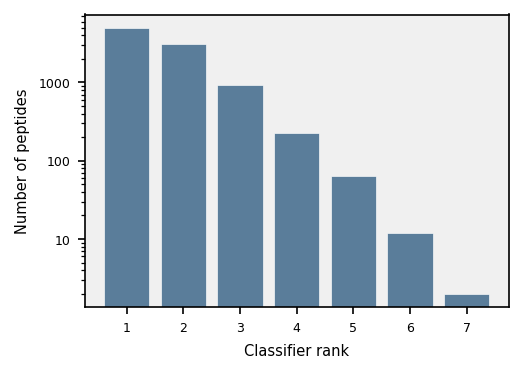

Classifier rank >= 6: 14 peptides
Classifier rank >= 7: 2 peptides


In [29]:
fig, ax = plt.subplots(figsize=(3.5, 2.5))
counts = clf_wide["classifier_rank"].value_counts().sort_index()
ax.bar(counts.index, counts.values, color="#5a7d9a", edgecolor="white", linewidth=0.3)
ax.set_xlabel("Classifier rank")
ax.set_ylabel("Number of peptides")
ax.set_yscale("log")
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
plt.tight_layout()
plt.show()

for rank in [6, 7]:
    n = (clf_wide["classifier_rank"] >= rank).sum()
    print(f"Classifier rank >= {rank}: {n} peptides")

Of 9,295 sequences, only 2 achieve rank 7 (unanimous agreement) and 12 reach
rank 6. At rank >= 5 there are 78 candidates - a ~100-fold reduction to a
tractable set for closer inspection.

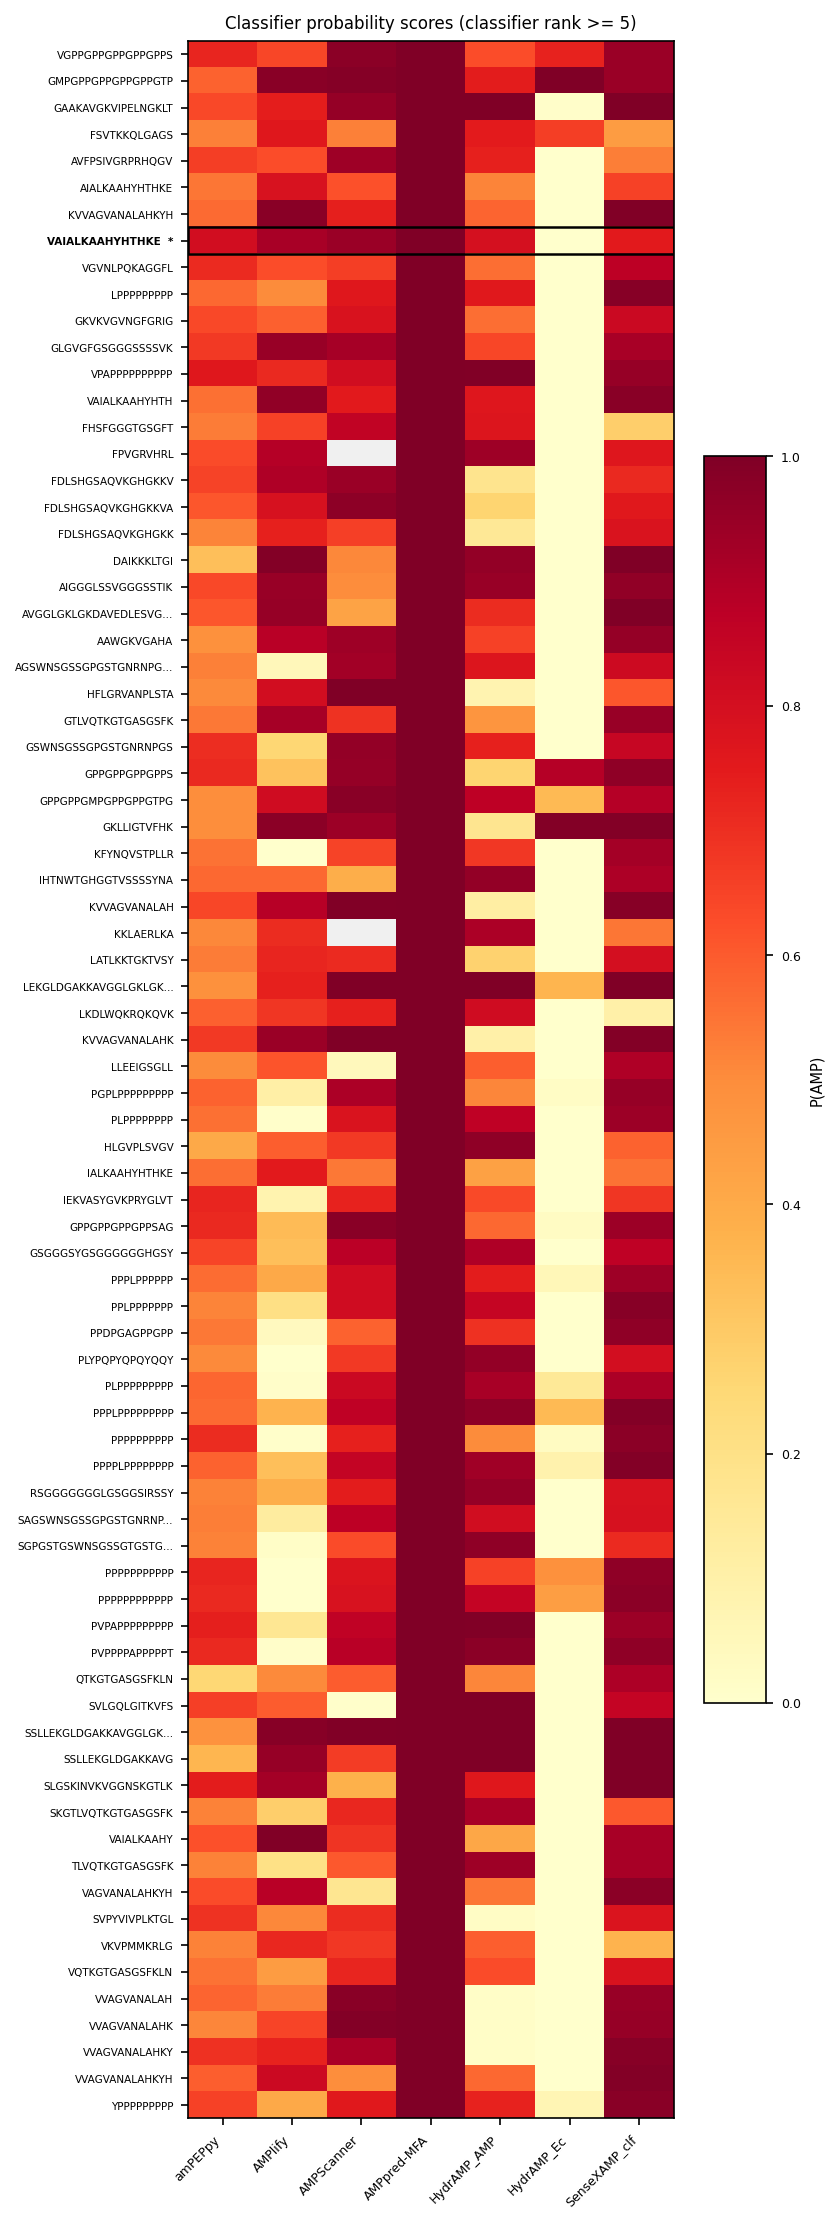

In [30]:
# Heatmap: probability scores for top candidates (classifier rank >= 5)
CALCITERMIN = "VAIALKAAHYHTHKE"
all_clf_cols = list(CLASSIFIERS.values())

top_mask = clf_wide["classifier_rank"] >= 5
top_seqs = clf_wide.loc[top_mask].sort_values("classifier_rank", ascending=False).index

heatmap_data = prob_wide.loc[prob_wide.index.isin(top_seqs), all_clf_cols]
heatmap_data = heatmap_data.loc[top_seqs]

labels = []
calc_row = None
for i, s in enumerate(heatmap_data.index):
    tag = s[:20] + "..." if len(s) > 20 else s
    if s == CALCITERMIN:
        tag = tag + "  *"
        calc_row = i
    labels.append(tag)

fig, ax = plt.subplots(figsize=(5.5, max(2.5, len(heatmap_data) * 0.18 + 0.8)))
im = ax.imshow(heatmap_data.values, aspect="auto", cmap="YlOrRd", vmin=0, vmax=1)
ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns, rotation=45, ha="right")
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=5)
if calc_row is not None:
    ax.get_yticklabels()[calc_row].set_fontweight("bold")
    ax.add_patch(Rectangle((-0.5, calc_row - 0.5), len(heatmap_data.columns), 1,
                           fill=False, edgecolor="black", linewidth=1.2))
ax.set_title("Classifier probability scores (classifier rank >= 5)")
plt.colorbar(im, ax=ax, label="P(AMP)", shrink=0.6)
plt.tight_layout()
plt.show()

AMPpred-MFA scores near 1.0 across the board (FPR ~1.0 on GeneralActivity;
BATTLE-AMP Fig. 2b), so its column adds little beyond a systematic +1 to the rank.
HydrAMP_Ec is the most informative column here: trained on MIC-supervised labels
rather than database membership, it maintains FPR 0.22 vs. >78% for binary
classifiers (BATTLE-AMP Fig. 2b) and flags a genuinely smaller candidate set.

## 7. MIC estimates

Having identified the top classifier candidates, we ask how potent they might be
against *E. coli*. Four E. coli-relevant regressors are applied: SenseXAMP_Ec,
APEX_Ec, MBC-Attention, and AMPredictor. Colormap: red = low MIC (potent), white
= 32 µM (activity threshold), blue = high MIC. In the BATTLE-AMP benchmark, only
MBC-Attention and AMPredictor achieve positive R² on *E. coli* ATCC 25922 (both
0.23, rho = 0.53 and 0.52; Szymczak et al., Fig. 3b) - treat the others as
coarse filters rather than calibrated estimates.

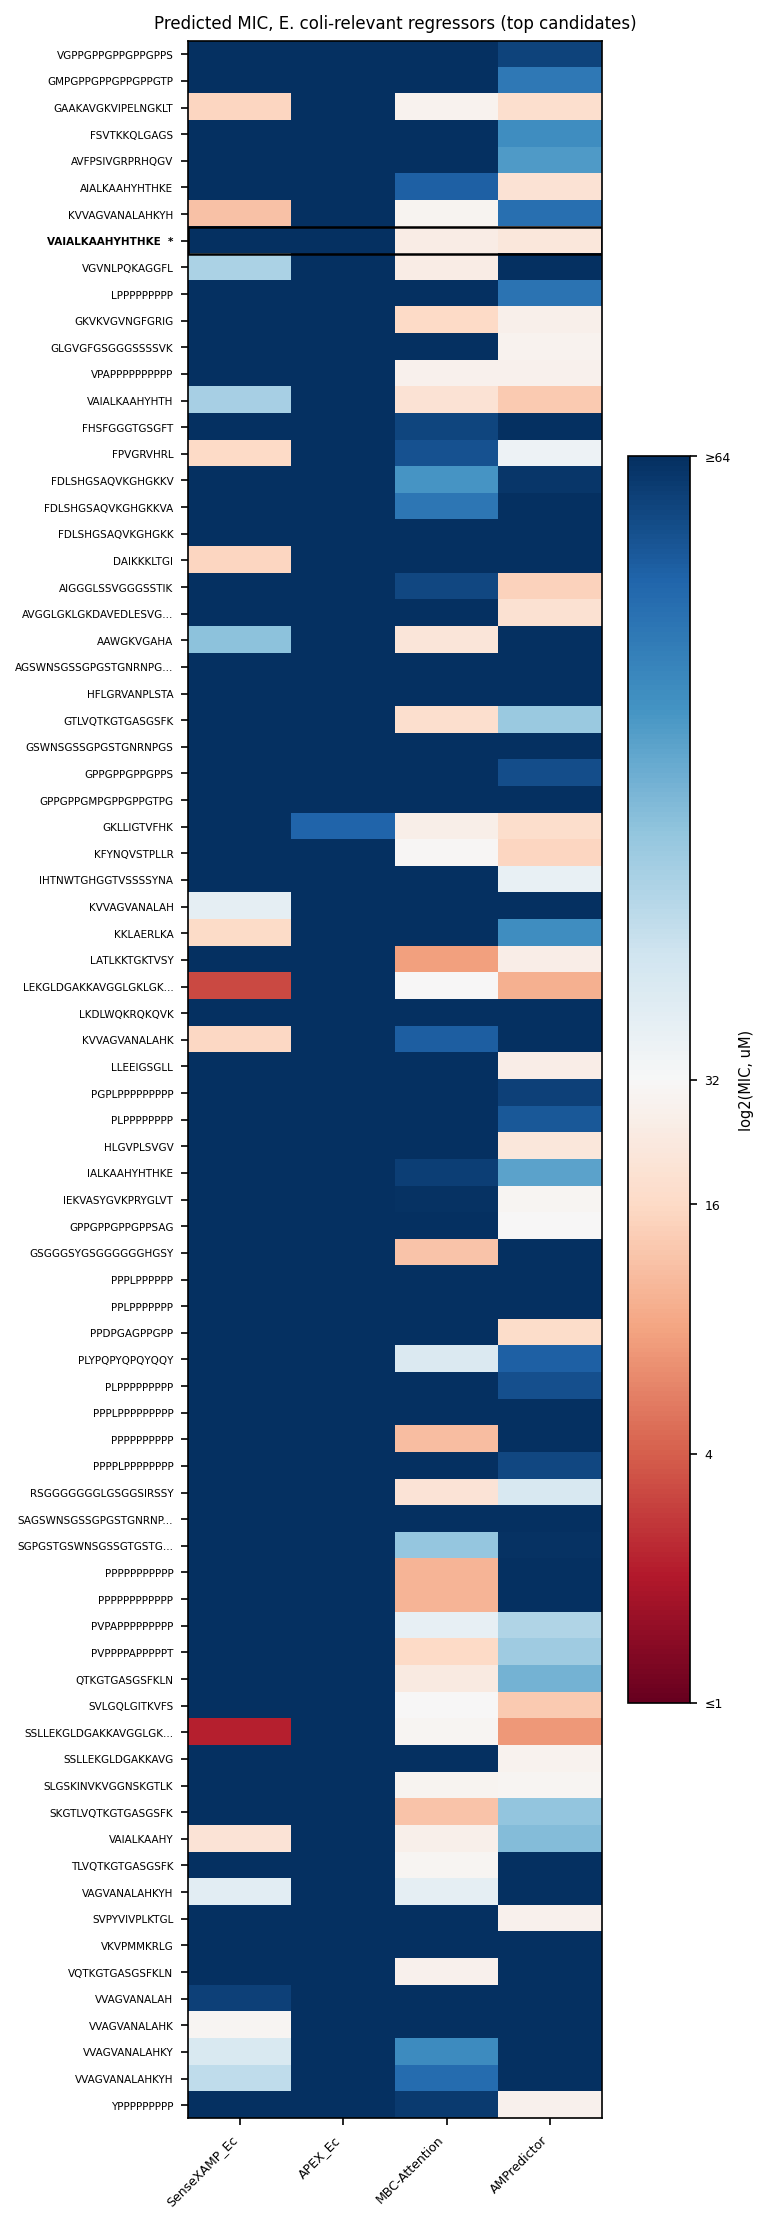

In [26]:
# Focus on E. coli-relevant regressors + AMPredictor
ecoli_regressors = ["SenseXAMP_Ec", "APEX_Ec", "MBC-Attention", "AMPredictor"]

top_reg = reg_wide.loc[reg_wide.index.isin(top_seqs), ecoli_regressors].copy()
top_reg = top_reg.loc[top_seqs]  # preserve rank order

# Convert to log2 (values already clamped to [0.25, 512] uM)
top_reg_log2 = np.log2(top_reg)

# Labels with calcitermin callout
labels_reg = []
calc_row_reg = None
for i, s in enumerate(top_reg.index):
    tag = s[:20] + "..." if len(s) > 20 else s
    if s == CALCITERMIN:
        tag = tag + "  *"
        calc_row_reg = i
    labels_reg.append(tag)

fig, ax = plt.subplots(figsize=(5, max(2.5, len(top_reg) * 0.18 + 0.8)))
norm_mic = TwoSlopeNorm(
    vmin=np.log2(1), vcenter=np.log2(32), vmax=np.log2(64)
)
im = ax.imshow(
    top_reg_log2.values, aspect="auto", cmap="RdBu", norm=norm_mic
)
ax.set_xticks(range(len(ecoli_regressors)))
ax.set_xticklabels(ecoli_regressors, rotation=45, ha="right")
ax.set_yticks(range(len(labels_reg)))
ax.set_yticklabels(labels_reg, fontsize=5)
if calc_row_reg is not None:
    ax.get_yticklabels()[calc_row_reg].set_fontweight("bold")
    ax.add_patch(Rectangle((-0.5, calc_row_reg - 0.5), len(ecoli_regressors), 1,
                           fill=False, edgecolor="black", linewidth=1.2))
ax.set_title("Predicted MIC, E. coli-relevant regressors (top candidates)")
cbar = plt.colorbar(im, ax=ax, label="log2(MIC, uM)", shrink=0.6)
cbar.set_ticks([np.log2(v) for v in [1, 4, 16, 32, 64]])
cbar.set_ticklabels(["\u22641", "4", "16", "32", "\u226564"])
plt.tight_layout()
plt.show()

Regressor disagreement is expected and itself informative: 11 of 14 regressors
have R² <= 0 on *E. coli* log2-MIC (Szymczak et al., Fig. 3b). Where MBC-Attention
and AMPredictor converge on a low MIC, there is a signal worth pursuing. Where
they diverge or return high values, confidence is low regardless of what the other
regressors show.

## 8. Combined ranking

Combining classifier rank with mean predicted MIC gives a single ranked list.
Database membership is shown alongside: a sequence already in DRAMP is a known AMP
and a built-in positive control; one present in DBAASP may have been seen during
model training.

In [32]:
# Build a combined ranking table
combined = clf_wide[["classifier_rank"]].copy()

mic_means = np.log2(reg_wide[ecoli_regressors]).mean(axis=1)
combined["mean_log2_MIC_Ec"] = mic_means

# Add HydrAMP_Ec prediction (MIC-supervised classifier, most selective)
combined["HydrAMP_Ec"] = clf_wide.get("HydrAMP_Ec", pd.Series(dtype=str))

# Join database membership flags
db_flags = seqs.set_index("sequence")[["in_dramp", "in_dbaasp"]]
combined = combined.join(db_flags)

combined = combined.sort_values(
    ["classifier_rank", "mean_log2_MIC_Ec"], ascending=[False, True]
)

display_cols = ["classifier_rank", "HydrAMP_Ec", "mean_log2_MIC_Ec", "in_dramp", "in_dbaasp"]
top20 = combined.head(20)[display_cols].copy()
top20["mean_log2_MIC_Ec"] = top20["mean_log2_MIC_Ec"].round(1)
top20.index = [s[:30] + "..." if len(s) > 30 else s for s in top20.index]
print("Top 20 candidate peptides")
print("=" * 75)
print(top20.to_string())

Top 20 candidate peptides
                           classifier_rank HydrAMP_Ec  mean_log2_MIC_Ec  in_dramp  in_dbaasp
VGPPGPPGPPGPPGPPS                        7        AMP               7.2     False      False
GMPGPPGPPGPPGPPGTP                       7        AMP               7.3     False      False
GAAKAVGKVIPELNGKLT                       6    non-AMP               5.0     False      False
VAIALKAAHYHTH                            6    non-AMP               5.0     False      False
KVVAGVANALAHKYH                          6    non-AMP               5.2     False      False
VGVNLPQKAGGFL                            6    non-AMP               5.8     False      False
GKVKVGVNGFGRIG                           6    non-AMP               6.1     False      False
VAIALKAAHYHTHKE                          6    non-AMP               6.2      True       True
VPAPPPPPPPPPP                            6    non-AMP               6.4     False      False
AIALKAAHYHTHKE                           6  

## 9. Calcitermin

Three S100A12 C-terminal fragments immediately stand out in the ranking: VAIALKAAHY
(10 aa, rank 5), VAIALKAAHYHTH (13 aa, rank 6), and VAIALKAAHYHTHKE (15 aa, rank 6).
S100A12 is strongly upregulated in PN kidney tissue and urine (Borgards et al.,
Figs. 2-3), making its proteolytic fragments plausible antimicrobial candidates.

Checking the databases: VAIALKAAHYHTHKE is already in both DRAMP and DBAASP - it is
Calcitermin, a known AMP. The two shorter variants are absent from both databases and
are novel to the models; no experimental activity data exist for either, so they
remain computational predictions at this stage.

Borgards et al. followed up on Calcitermin experimentally: it was confirmed in patient
urine by PRM-LC-MS/MS at 20.3-53.2 fmol/µg native peptides (Fig. 5D), and shown to
inhibit UPEC strain 536 with an MIC of 4 µM at pH 5.0. Activity was absent at pH 7.0
- the acidic urinary microenvironment at the infection site is required (Fig. 5E).

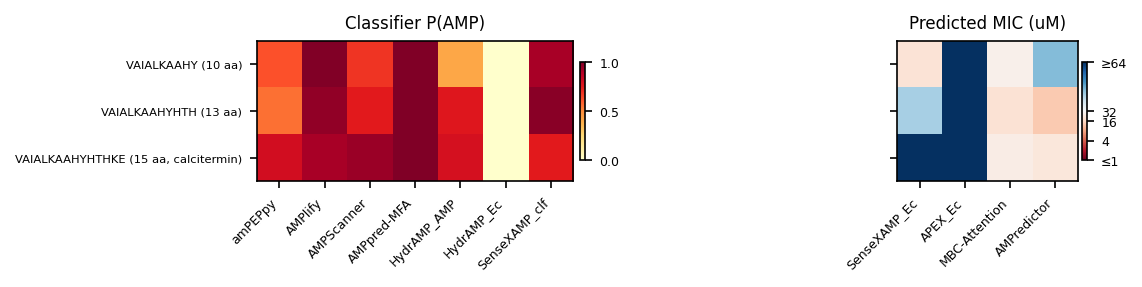

Calcitermin variant predictions (E. coli regressors, MIC in uM):
  VAIALKAAHY (10 aa): classifier_rank=5, SenseXAMP_Ec=19.7, APEX_Ec=128.8, MBC-Attention=26.9, AMPredictor=43.1
  VAIALKAAHYHTH (13 aa): classifier_rank=6, SenseXAMP_Ec=40.4, APEX_Ec=111.6, MBC-Attention=19.5, AMPredictor=12.9
  VAIALKAAHYHTHKE (15 aa, calcitermin): classifier_rank=6, SenseXAMP_Ec=512.0, APEX_Ec=121.4, MBC-Attention=24.5, AMPredictor=21.8


In [33]:
calc_seqs = ["VAIALKAAHY", "VAIALKAAHYHTH", "VAIALKAAHYHTHKE"]
calc_labels = ["VAIALKAAHY (10 aa)", "VAIALKAAHYHTH (13 aa)", "VAIALKAAHYHTHKE (15 aa, calcitermin)"]

# Classifier probability scores
calc_clf = prob_wide.loc[prob_wide.index.isin(calc_seqs), all_clf_cols].copy()
calc_clf = calc_clf.loc[calc_seqs]

fig, axes = plt.subplots(1, 2, figsize=(7.5, 1.8), layout="constrained",
                         gridspec_kw={"width_ratios": [7, 4], "wspace": 0.4})

# Panel A: classifier probabilities
ax = axes[0]
im = ax.imshow(calc_clf.values, aspect="auto", cmap="YlOrRd", vmin=0, vmax=1)
ax.set_xticks(range(len(calc_clf.columns)))
ax.set_xticklabels(calc_clf.columns, rotation=45, ha="right")
ax.set_yticks(range(len(calc_labels)))
ax.set_yticklabels(calc_labels, fontsize=5.5)
ax.set_title("Classifier P(AMP)")
plt.colorbar(im, ax=ax, shrink=0.7, pad=0.02)

# Panel B: E. coli regressor MICs
calc_reg = reg_wide.loc[reg_wide.index.isin(calc_seqs), ecoli_regressors].copy()
calc_reg = calc_reg.loc[calc_seqs]
calc_reg_log2 = np.log2(calc_reg)

ax = axes[1]
norm_calc = TwoSlopeNorm(
    vmin=np.log2(1), vcenter=np.log2(32), vmax=np.log2(64)
)
im2 = ax.imshow(calc_reg_log2.values, aspect="auto", cmap="RdBu", norm=norm_calc)
ax.set_xticks(range(len(ecoli_regressors)))
ax.set_xticklabels(ecoli_regressors, rotation=45, ha="right")
ax.set_yticks(range(len(calc_labels)))
ax.set_yticklabels([])
ax.set_title("Predicted MIC (uM)")
cbar = plt.colorbar(im2, ax=ax, shrink=0.7, pad=0.02)
cbar.set_ticks([np.log2(v) for v in [1, 4, 16, 32, 64]])
cbar.set_ticklabels(["\u22641", "4", "16", "32", "\u226564"])

plt.show()

# Print raw numbers
print("Calcitermin variant predictions (E. coli regressors, MIC in uM):")
for seq, label in zip(calc_seqs, calc_labels):
    rank = int(clf_wide.loc[seq, "classifier_rank"])
    mics = ", ".join(f"{n}={reg_wide.loc[seq, n]:.1f}" for n in ecoli_regressors)
    print(f"  {label}: classifier_rank={rank}, {mics}")

**HydrAMP_Ec** assigns near-zero probability to all three variants (P < 0.001).
At first glance this looks like a false negative - five other classifiers agree
these are AMPs. The explanation comes from the experimental data: Calcitermin is
only active at pH 5.0, not pH 7.0 (Borgards et al., Fig. 5E). DBAASP records MIC
under standard broth microdilution at pH 7.0, where Calcitermin is inactive and
therefore labelled negative in HydrAMP_Ec's training data. The model is not wrong -
it correctly predicts inactivity under standard assay conditions. This is a good
illustration of why experimental context matters when reading a near-zero HydrAMP_Ec
score: it does not rule out activity under different conditions.

**MBC-Attention and AMPredictor** are the two regressors we would trust most here
(best E. coli performance in BATTLE-AMP: R2 = 0.23, rho = 0.53 and 0.52;
Szymczak et al., Fig. 3b). They give consistent predictions across all three
variants: MBC-Attention 27/20/25 µM, AMPredictor 43/13/22 µM. Both place the
variants in the 13-43 µM range, directionally consistent with the experimental
4 µM at pH 5.0 given the ~3-5 log2-unit uncertainty typical for these regressors.

**APEX_Ec** returns 129/112/121 µM across all three variants - nearly identical
values regardless of sequence. This is characteristic of APEX on this dataset:
it preserves rough rank order but regresses toward the population mean, making it
unsuitable for distinguishing between the three fragments.

**SenseXAMP_Ec** predicts 20/40/512 µM for the 10, 13, and 15 aa variants - a >12-fold jump between the 13 aa and 15 aa forms despite those two sequences
differing by only two C-terminal residues (KE). SenseXAMP operates primarily on
amino acid composition rather than residue order (BATTLE-AMP Fig. 4b-c): adding
hydrophilic residues is enough to drive predicted MIC from 40 to >512 µM,
even though the first 13 residues are shared between the two variants.
